<a href="https://colab.research.google.com/github/KadenLu/Kaden-s-Individual-Project/blob/main/Kaden's_Attempt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
from google.colab import drive
import random

# 1. Mount Google Drive
drive.mount('/content/drive')

# Set the base directory path based on your folder name
base_path = '/content/drive/MyDrive/kaden_projects/'

print("Loading and filtering users...")
# 2. Load users and filter demographics
# We drop rows where key demographic/personal data is missing (NaN)
users = pd.read_csv(base_path + 'users_cleaned.csv')
demographic_cols = ['gender', 'location', 'birth_date']
cols_to_check = [c for c in demographic_cols if c in users.columns] # Failsafe in case of slight schema variations
users_valid = users.dropna(subset=cols_to_check)
valid_usernames = set(users_valid['username'])

print("Loading anime means...")
# 3. Load anime mean scores
# We only need the anime ID and the global mean score for that anime
anime = pd.read_csv(base_path + 'anime_cleaned.csv', usecols=['anime_id', 'score'])
anime = anime.rename(columns={'score': 'anime_mean_score'})

print("Loading, sampling, and filtering animelists... (This might take a moment)")

file_path = base_path + 'animelists_cleaned.csv'
sample_size = 5000000

print("Reading and sampling the CSV directly into memory...")
# 4. Read the CSV, top 5 million
animelists = pd.read_csv(
    file_path,
    usecols=['username', 'anime_id', 'my_score'], # Still a good idea to only keep needed columns
    nrows=sample_size
)

# Filter out invalid ratings (<= 0 or > 10)
animelists = animelists[(animelists['my_score'] > 0) & (animelists['my_score'] <= 10)]

# Filter out users with no demographic data
animelists = animelists[animelists['username'].isin(valid_usernames)]

# Filter out users who have rated less than 6 anime (within this sample)
user_counts = animelists['username'].value_counts()
users_with_enough_ratings = user_counts[user_counts >= 6].index
animelists = animelists[animelists['username'].isin(users_with_enough_ratings)]

print("Calculating metrics...")
# 5. Merge lists with anime global scores to calculate the difference
animelists = animelists.merge(anime, on='anime_id', how='inner')
animelists['score_diff'] = animelists['my_score'] - animelists['anime_mean_score']

# 6. Generate the final dataframe with personal variance and avg score difference
final_user_stats = animelists.groupby('username').agg(
    personal_variance=('my_score', 'var'),
    avg_score_diff=('score_diff', 'mean')
).reset_index()

print("\n--- Final DataFrame ---")
display(final_user_stats.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading and filtering users...
Loading anime means...
Loading, sampling, and filtering animelists... (This might take a moment)
Reading and sampling the CSV directly into memory...
Calculating metrics...

--- Final DataFrame ---


,username,personal_variance,avg_score_diff
0,--FallenAngel--,0.953800,0.821432
1,-Ackerman,1.191734,-0.229811
2,-Alicia-San-,3.109397,-0.671935
3,-Anna-,3.263885,-0.278576
4,-Araragi-,0.923803,0.256151
5,-Arlequin-,2.352659,-1.366895
6,-Ayumi-,0.474798,1.365312
7,-Azazel-,3.277914,-0.413873
8,-Azure-,2.421539,-2.934568
9,-Balmung-,1.692010,-1.287918


In [14]:
final_user_stats.shape

(11335, 4)

<Axes: >

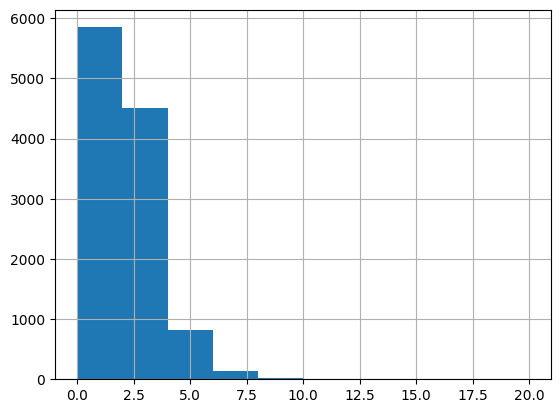

In [15]:
final_user_stats.personal_variance.hist()

<Axes: >

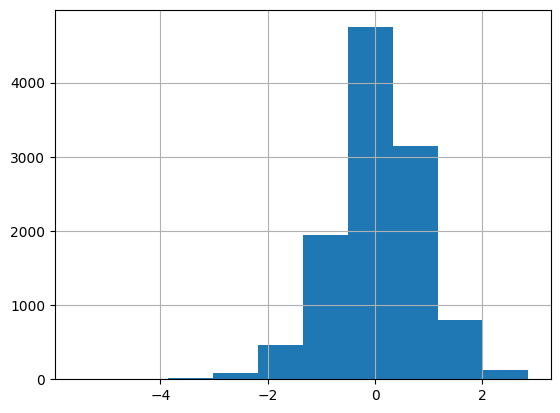

In [16]:
final_user_stats.avg_score_diff.hist()

In [17]:
final_user_stats.avg_score_diff.mean()

np.float64(0.051132099038930005)

Preparing data for clustering...
Running K-Means and generating plots with centroids...


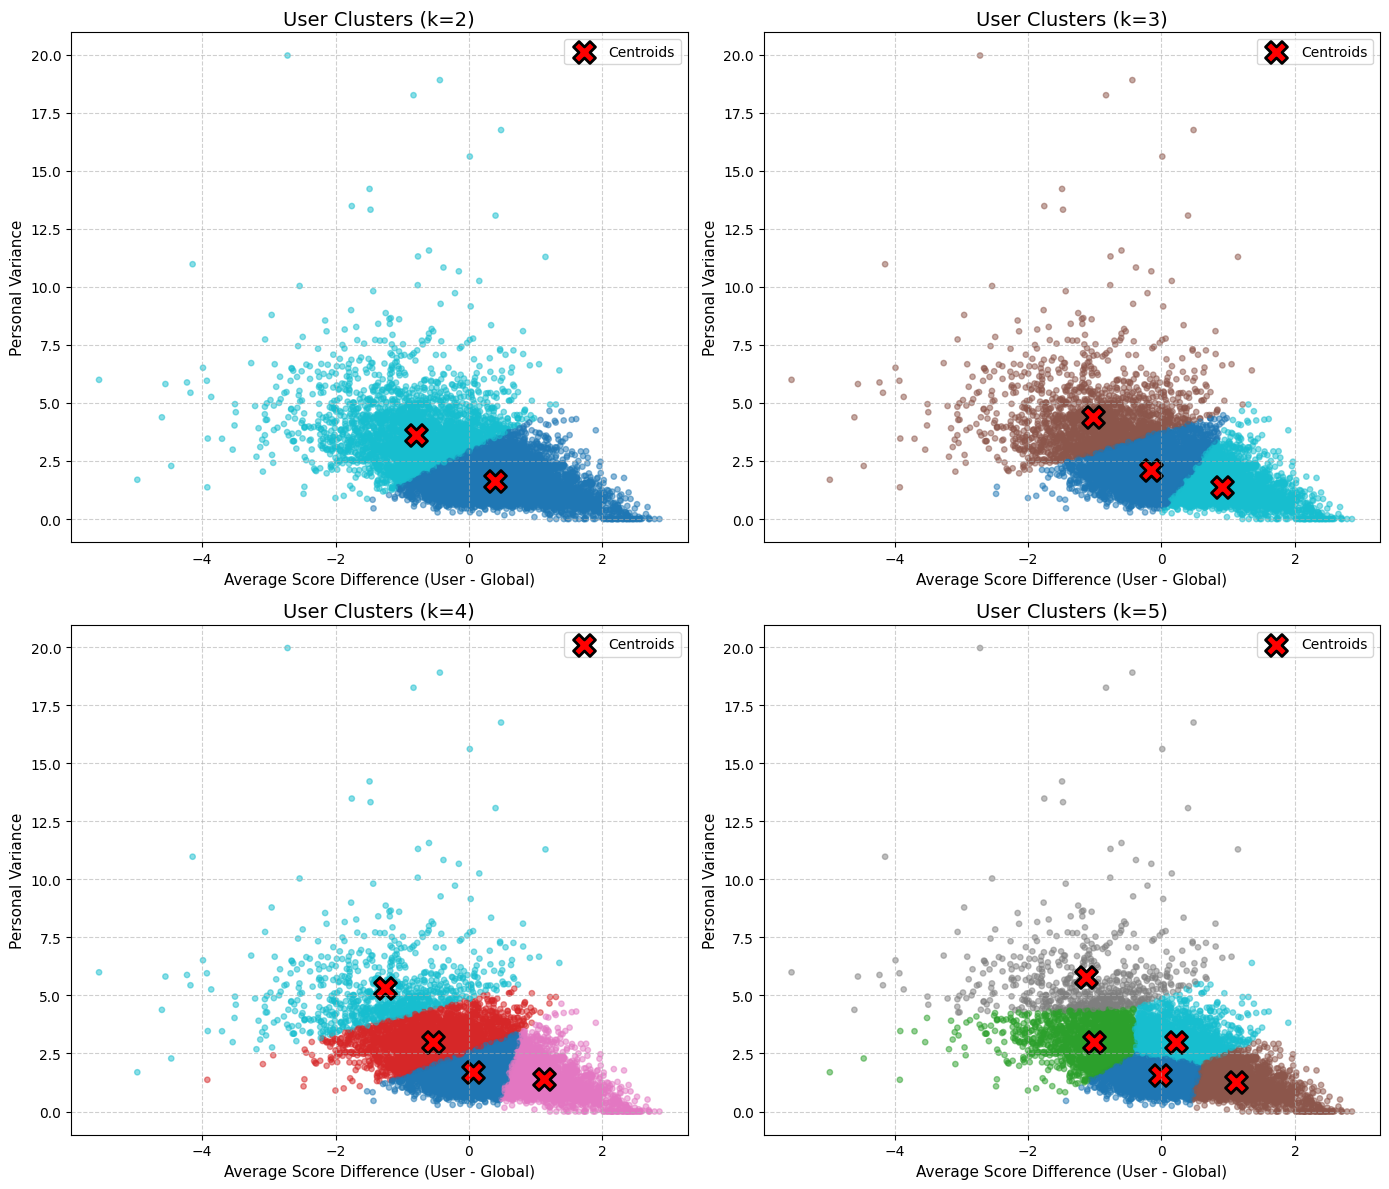

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("Preparing data for clustering...")
# 1. Isolate the features we want to use
cluster_df = final_user_stats[['personal_variance', 'avg_score_diff']].dropna()

# 2. Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

print("Running K-Means and generating plots with centroids...")
# 3. Set up a 2x2 grid of subplots for our visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

k_values = [2, 3, 4, 5]

for i, k in enumerate(k_values):
    # Initialize and fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_features)

    # --- NEW: Extract and un-scale the centroids ---
    # Get centroids in the scaled space
    scaled_centroids = kmeans.cluster_centers_
    # Revert centroids back to original units (Variance and Score Diff)
    original_centroids = scaler.inverse_transform(scaled_centroids)

    # Plot on the corresponding subplot
    ax = axes[i]

    # Plot the user data points
    scatter = ax.scatter(
        cluster_df['avg_score_diff'],
        cluster_df['personal_variance'],
        c=cluster_labels,
        cmap='tab10',
        alpha=0.5,
        s=15
    )

    # --- NEW: Plot the centroids ---
    # original_centroids[:, 1] is avg_score_diff (X-axis)
    # original_centroids[:, 0] is personal_variance (Y-axis)
    ax.scatter(
        original_centroids[:, 1],
        original_centroids[:, 0],
        c='red',             # Bright color to stand out
        marker='X',          # Distinct shape
        s=250,               # Large size
        edgecolors='black',  # Black border for contrast
        linewidths=2,
        label='Centroids'
    )

    ax.set_title(f'User Clusters (k={k})', fontsize=14)
    ax.set_xlabel('Average Score Difference (User - Global)', fontsize=11)
    ax.set_ylabel('Personal Variance', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add a legend just to label the centroid
    ax.legend()

plt.tight_layout()
plt.show()

Calculating WCSS and Silhouette Scores for k=2 through k=10...
Generating evaluation plots...


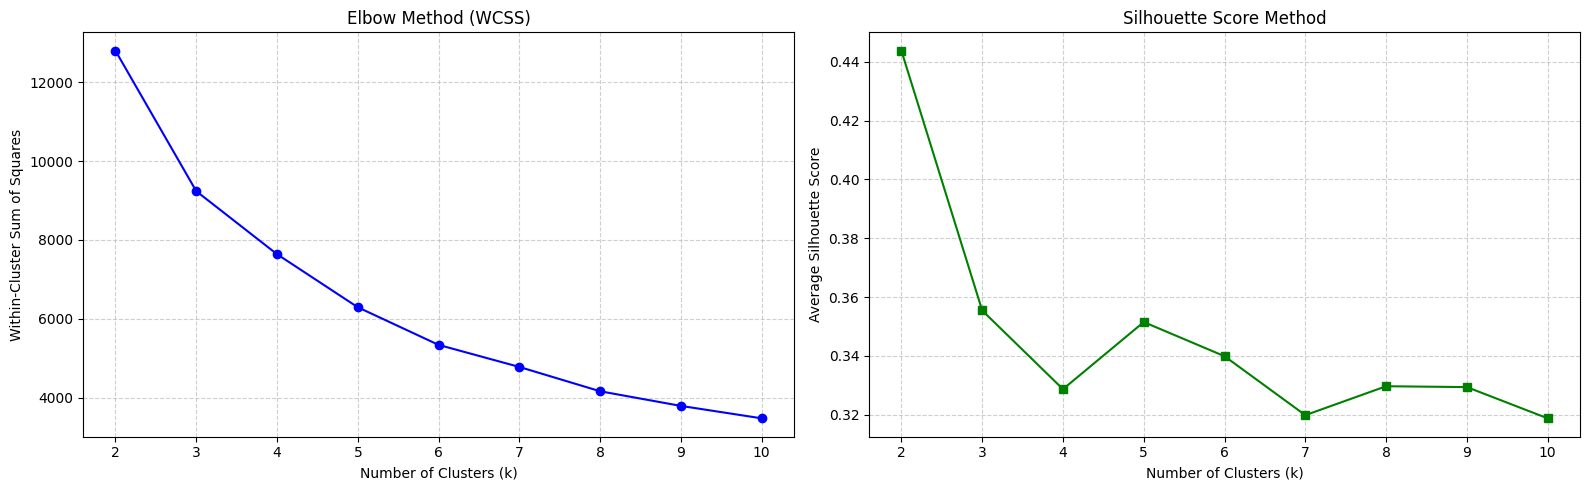

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

print("Calculating WCSS and Silhouette Scores for k=2 through k=10...")
# Define the range of k we want to test
k_range = range(2, 11)

wcss = []
silhouette_scores = []

for k in k_range:
    # Fit the model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_features)

    # 1. Append WCSS (Inertia)
    wcss.append(kmeans.inertia_)

    # 2. Append Silhouette Score
    # Note: If your sample is exactly 5 million, silhouette_score will crash your RAM!
    # It calculates pairwise distances. We take a random sample of 50,000 to calculate the score.
    score = silhouette_score(scaled_features, cluster_labels, random_state=42)
    silhouette_scores.append(score)

print("Generating evaluation plots...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elbow Method (WCSS)
ax1.plot(k_range, wcss, marker='o', linestyle='-', color='b')
ax1.set_title('Elbow Method (WCSS)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Within-Cluster Sum of Squares')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Silhouette Score Method')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

print("Running K-Means (k=3)...")
# 1. Prep and scale the data again just to be safe
cluster_df = final_user_stats[['personal_variance', 'avg_score_diff']].dropna()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)

# 2. Fit the model
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(scaled_features)

# 3. Add the raw numeric labels (0, 1, 2) temporarily
cluster_df['cluster_num'] = cluster_labels

# 4. Find out which cluster number is which based on their score difference
# We group by the cluster number and find the mean of 'avg_score_diff'
cluster_means = cluster_df.groupby('cluster_num')['avg_score_diff'].mean()

# Sort them: lowest score diff -> Critical, middle -> Average, highest -> Generous
sorted_clusters = cluster_means.sort_values().index.tolist()

critical_label = sorted_clusters[0]
average_label = sorted_clusters[1]
generous_label = sorted_clusters[2]

# 5. Create a mapping dictionary to convert the numbers to our human names
label_mapping = {
    critical_label: 'Critical',
    average_label: 'Average',
    generous_label: 'Generous' # Change this string to whatever name you chose!
}

print("Applying labels to the dataframe...")
# 6. Map the names to a brand new column
cluster_df['user_persona'] = cluster_df['cluster_num'].map(label_mapping)

# 7. Merge this back into your main final_user_stats dataframe
# We use a left merge on the index to ensure everything lines up perfectly
final_user_stats = final_user_stats.merge(
    cluster_df[['user_persona']],
    left_index=True,
    right_index=True,
    how='left'
)

print("\n--- Labeled DataFrame ---")
display(final_user_stats.head(10))

Running K-Means (k=3)...
Applying labels to the dataframe...

--- Labeled DataFrame ---


,username,personal_variance,avg_score_diff,user_persona
0,--FallenAngel--,0.953800,0.821432,Generous
1,-Ackerman,1.191734,-0.229811,Average
2,-Alicia-San-,3.109397,-0.671935,Average
3,-Anna-,3.263885,-0.278576,Average
4,-Araragi-,0.923803,0.256151,Generous
5,-Arlequin-,2.352659,-1.366895,Average
6,-Ayumi-,0.474798,1.365312,Generous
7,-Azazel-,3.277914,-0.413873,Average
8,-Azure-,2.421539,-2.934568,Critical
9,-Balmung-,1.692010,-1.287918,Average
